# Photoplethysmogram (PPG) heart beat estimation model

## 1. Model building and training

## 1.1. Library import

In [5]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [7]:
!pip install pandas matplotlib heartpy scikit-learn

In [82]:
import pandas as pd
import numpy as np
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
import math # sqrt for magnitude
from scipy import signal
%matplotlib inline
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import heartpy as hp
import sklearn
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
import pickle
from keras.wrappers.scikit_learn import KerasRegressor

## 1.2. Loading csv

In [12]:
all_subjects_csv = pd.read_csv("all_subjects.csv")
all_subjects_csv

,Subject,0,1,2,3,4,5,6,7,8,...,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312
0,Subject 1,7.28,6.33,5.46,4.60,3.74,2.86,2.03,1.27,0.57,...,32.15,32.15,32.13,32.13,32.13,32.13,32.15,32.15,32.15,49.611369
1,Subject 1,6.34,9.78,12.97,15.82,18.17,19.99,21.33,22.39,23.37,...,32.15,32.15,32.16,32.16,32.16,32.16,32.15,32.15,32.15,50.323992
2,Subject 1,7.70,6.02,4.23,2.46,0.74,-0.93,-2.62,-4.36,-6.16,...,32.15,32.15,32.15,32.15,32.15,32.15,32.13,32.13,32.13,52.708336
3,Subject 1,-120.35,-108.51,-98.97,-91.45,-84.97,-78.29,-70.36,-60.68,-49.41,...,32.13,32.13,32.15,32.15,32.15,32.15,32.13,32.13,32.13,55.640794
4,Subject 1,-7.06,-10.67,-14.96,-19.60,-24.25,-28.65,-32.73,-36.59,-40.43,...,32.13,32.13,32.13,32.13,32.13,32.13,32.15,32.15,32.15,57.658406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64742,Subject 15,24.22,23.34,22.43,21.48,20.36,19.04,17.55,16.05,14.67,...,34.00,33.99,33.99,33.99,33.99,33.99,33.99,33.99,33.99,80.853007
64743,Subject 15,-35.83,-38.20,-39.20,-38.33,-35.31,-30.30,-23.76,-16.46,-9.23,...,33.99,33.99,33.99,33.99,33.99,NaN,NaN,NaN,NaN,NaN
64744,Subject 15,2.07,1.52,0.42,-0.96,-2.35,-3.55,-4.53,-5.45,-6.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64745,Subject 15,15.63,14.74,13.91,12.97,11.83,10.51,9.09,7.69,6.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3. Data preprocessing functions

In [15]:
## Filtering
def magnitude_hyper(x, y, z):
    sq = math.sqrt(x**2 + y**2 + z**2)
    return sq

def filter_ppg_testing_hyper(segment_ppg_full, segment_acc_values):
    """
    Filter the ppg data using a lowpass filter with a 4 Hz cut off frequency and factoring by 0.6.
    Return the ppg cleaned numpy array.

    segment_ppg_full = ppg numpy array that gets cleaned
    segment_acc_values = accelerometer numpy array
    """
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude_hyper(segment_acc_values.iloc[vector], segment_acc_values.iloc[vector + 1],segment_acc_values.iloc[vector + 2])) # this is the three channels into one

    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_full_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - segment_ppg_full_mean) / segment_ppg_full_std # z normalisation

    # x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))

    ppg_downsampled = signal.resample(segment_ppg_full_normalized, len(x_acc_normalized)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling

    isolated_ppg = (ppg_downsampled - (x_acc_normalized*0.6)) * 0.6
    ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 4, sample_rate = 32.0, order = 5, filtertype='lowpass')
    # plt.figure(figsize=(20,10))
    # plt.plot(ppg_downsampled, linewidth=2 ,label='raw ppg')
    # plt.plot(acc_first_seg_vector_x, linewidth=2 ,label=f'x')
    # plt.plot(acc_first_seg_vector_y, linewidth=2 ,label=f'y')
    # plt.plot(acc_first_seg_vector_z, linewidth=2 ,label=f'z')
    # plt.plot(x_acc_downsampled, label='raw magnitude')
    # plt.ylim((-4,5))
    # plt.legend()
    # plt.show()
    return ppg_cleaned
# segment_ppg_full = []
# segment_label = subject_dataframes['Subject 1'].iloc[0, -1]
# segment_ppg_values = subject_dataframes['Subject 1'].iloc[0, 43:514]
# second_seg_ppg = subject_dataframes['Subject 1'].iloc[0+1, 2:43]
# segment_acc_values = subject_dataframes['Subject 1'].iloc[0, 514:1282]
# segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
# ppg_cleaned = filter_ppg_testing(segment_ppg_full, segment_acc_values)

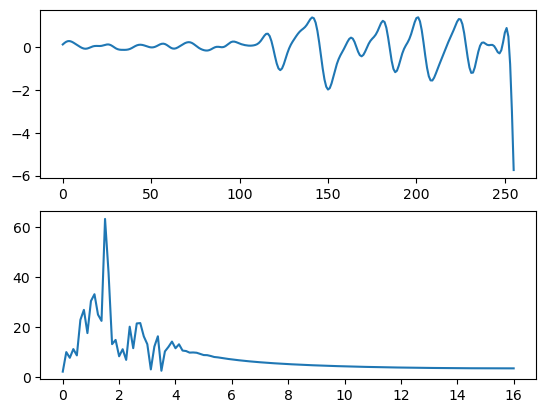

In [84]:
def full_channels_2d_arr_segment_testing_hyper(dataset, index):
    """
    Retrieve the values from the single channel of the PPG and the three-axis channels of the accelerometer, apply rFFT and z-normalisation on them.
    Return the 2d numpy array (Nch x Nfft).

    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points

    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_ppg_full = []
    segment_label = dataset.iloc[index, -1]
    segment_ppg_values = dataset.iloc[index, 43:514]
    second_seg_ppg = dataset.iloc[index+1, 2:43]
    segment_acc_values = dataset.iloc[index, 514:1282]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])

    ppg_cleaned = filter_ppg_testing_hyper(segment_ppg_full, segment_acc_values)

    ## GETTING THE ACCELEROMETER AXIS
    acc_first_seg_vector_x = [] # variable that holds the accelerometer vector x
    acc_first_seg_vector_y = [] # variable that holds the accelerometer vector y
    acc_first_seg_vector_z = [] # variable that holds the accelerometer vector z
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector_x.append(segment_acc_values.iloc[vector])
        acc_first_seg_vector_y.append(segment_acc_values.iloc[vector+1])
        acc_first_seg_vector_z.append(segment_acc_values.iloc[vector+2])

    ppg_downsampled = signal.resample(ppg_cleaned, len(acc_first_seg_vector_x)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling

    ## ACCELEROMETER X FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector_x) # number of samples in 8 seconds
    acc_first_seg_vector_rfft_x = rfft(acc_first_seg_vector_x)
    acc_first_seg_vector_rfftfreq_x = rfftfreq(N, 1/SAMPLE_RATE)

    df_acc_seg_rfft_x = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_x, 'movement': acc_first_seg_vector_rfft_x}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_x = df_acc_seg_rfft_x[df_acc_seg_rfft_x['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['frequency'])
    df_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['movement'])
    df_acc_seg_arr_x_new_arr = []
    for i in range(0,len(df_acc_seg_arr_x)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].real)
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].imag)
    df_acc_seg_arr_x = np.array(df_acc_seg_arr_x_new_arr)
    # acc_seg_irfft_x = irfft(df_acc_seg_arr_x)

    ## ACCELEROMETER Y FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_y = rfft(acc_first_seg_vector_y)
    acc_first_seg_vector_rfftfreq_y = rfftfreq(N, 1/SAMPLE_RATE)

    df_acc_seg_rfft_y = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_y, 'movement': acc_first_seg_vector_rfft_y}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_y = df_acc_seg_rfft_y[df_acc_seg_rfft_y['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['frequency'])
    df_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['movement'])
    df_acc_seg_arr_y_new_arr = []
    for i in range(0,len(df_acc_seg_arr_y)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].real)
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].imag)
    df_acc_seg_arr_y = np.array(df_acc_seg_arr_y_new_arr)
    # print(df_acc_seg_arr_y)
    # acc_seg_irfft_y = irfft(df_acc_seg_arr_y)

    ## ACCELEROMETER Z FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_z = rfft(acc_first_seg_vector_z)
    acc_first_seg_vector_rfftfreq_z = rfftfreq(N, 1/SAMPLE_RATE)

    df_acc_seg_rfft_z = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_z, 'movement': acc_first_seg_vector_rfft_z}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_z = df_acc_seg_rfft_z[df_acc_seg_rfft_z['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['frequency'])
    df_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['movement'])
    df_acc_seg_arr_z_new_arr = []
    for i in range(0,len(df_acc_seg_arr_z)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].real)
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].imag)
    df_acc_seg_arr_z = np.array(df_acc_seg_arr_z_new_arr)

    ## PPG FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(ppg_cleaned) # number of samples in 8 seconds
    ppg_seg_vector_rfft = rfft(ppg_cleaned)
    ppg_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)

    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['frequency'])
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])    
    df_ppg_seg_arr_new_arr = []
    for i in range(0,len(df_ppg_seg_arr)): # get rid of the imaginary part and increment it as a real number
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].real)
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].imag)
    df_ppg_seg_arr = np.array(df_ppg_seg_arr_new_arr)
    # ppg_seg_irfft = irfft(df_ppg_seg_arr)

    # ACCELEROMETER X NORMALISATION ON THE FFT
    acc_rfft_mean_x = np.mean(df_acc_seg_arr_x) # mean
    acc_rfft_std_x = np.std(df_acc_seg_arr_x) # standard deviation
    acc_rfft_normalized_x = (df_acc_seg_arr_x - acc_rfft_mean_x) / acc_rfft_std_x # z normalisation

    ## ACCELEROMETER Y NORMALISATION ON THE FFT
    acc_rfft_mean_y = np.mean(df_acc_seg_arr_y) # mean
    acc_rfft_std_y = np.std(df_acc_seg_arr_y) # standard deviation
    acc_rfft_normalized_y = (df_acc_seg_arr_y - acc_rfft_mean_y) / acc_rfft_std_y # z normalisation

    ## ACCELEROMETER Z NORMALISATION ON THE FFT
    acc_rfft_mean_z = np.mean(df_acc_seg_arr_z) # mean
    acc_rfft_std_z = np.std(df_acc_seg_arr_z) # standard deviation
    acc_rfft_normalized_z = (df_acc_seg_arr_z - acc_rfft_mean_z) / acc_rfft_std_z # z normalisation

    ## PPG NORMALISATION ON THE FFT
    ppg_rfft_mean = np.mean(df_ppg_seg_arr) # mean
    ppg_rfft_std = np.std(df_ppg_seg_arr) # standard deviation
    ppg_rfft_normalized = (df_ppg_seg_arr - ppg_rfft_mean) / ppg_rfft_std # z normalisation

    # print(len(ppg_rfft_normalized),len(x_acc_downsampled),len(y_acc_downsampled),len(z_acc_downsampled))

    # CREATING THE 2D ARRAY CONTAINING THE FFT VALUES OF EACH CHANNEL PER FREQUENCY

    full_channel_2d_arr = np.array([ppg_rfft_normalized, acc_rfft_normalized_x, acc_rfft_normalized_y, acc_rfft_normalized_z])
    full_channel_2d_arr = np.reshape(full_channel_2d_arr,(66,4))
    # print(full_channel_2d_arr.shape)
    
    # plt.plot(acc_rfft_normalized_x)
    # plt.plot(acc_rfft_normalized_y)
    # plt.plot(acc_rfft_normalized_z)
    return full_channel_2d_arr
test_ = full_channels_2d_arr_segment_testing_hyper(subject_dataframes['Subject 1'], 567)

In [19]:
def get_labels_testing_hyper(dataset, index):
    """
    Get the label data point of the index and return it.

    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_label = dataset.iloc[index, -1]
    return segment_label

In [21]:
def range_inclusive_hyper(first_index, last_index): # Helper function
    return range(first_index, last_index+1)

def get_subject_segments_testing_hyper(dataset, first_index=0, last_index=4000):
    """
    Pull the N-indexes of the specific subject and return the 3d numpy array (Ntr x Nch x Nfft).

    Ntr = number of segments used together for heart rate estimation
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points

    Parameters:
    dataset = subject dataframe
    first_index = first segment index
    last_index = last segment index to
    """
    if(first_index <= last_index):
        input_list = []
        for index in range_inclusive_hyper(first_index, last_index):
            input_list.append(full_channels_2d_arr_segment_testing_hyper(all_subjects_csv, index))
        full_channels_3d_arr = np.stack(input_list, axis=0)
        return tf.convert_to_tensor(full_channels_3d_arr, dtype=tf.float32)
    else:
        print("It should be an increment order")
        return None

In [23]:
def get_labels_segments_testing_hyper(dataset, first_index=0, last_index=4000):
    """
    Get the label data points from the index range and return it as a numpy array.

    Parameters:
    dataset = subject dataframe
    first_index = first segment index
    last_index = last segment index to
    """
    if(first_index <= last_index):
        labels_list = []
        for index in range_inclusive_hyper(first_index, last_index):
            labels_list.append(get_labels_testing_hyper(all_subjects_csv, index))
        return tf.convert_to_tensor(np.array(labels_list), dtype=tf.float32)
    else:
        print("It should be an increment order")
        return None

In [25]:
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    mae = history.history['mae']
    val_mae = history.history['val_mae']

    epochs = range(len(history.history['loss']))

    # Plot loss
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.figure()
    plt.plot(epochs, mae, label='training_mae')
    plt.plot(epochs, val_mae, label='val_mae')
    plt.title('MAE')
    plt.xlabel('Epochs')
    plt.legend();


In [27]:
def separate_subjects(dataframe):
    unique_subjects = dataframe['Subject'].unique()

    subject_dataframes = {}

    for subject in unique_subjects:
        subject_df = dataframe[dataframe['Subject'] == subject].reset_index(drop=True)
        subject_dataframes[subject] = subject_df

    return subject_dataframes
subject_dataframes = separate_subjects(all_subjects_csv)

In [29]:
def plot_predictions(train_data,
                     train_labels,
                     test_data,
                     test_labels,
                     predictions):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.plot(train_data, train_labels, label="Training data")
    # Plot test data in green
    plt.plot(test_data, test_labels, label="Testing data")
    # Plot the predictions in red (predictions were made on the test data)
    plt.plot(test_data, predictions, label="Predictions")
    # Show the legend
    plt.legend();

In [12]:
# with 200 epochs - result: mae 6.230376415252685 and std 2.137932034321378
def create_model_hyper(subject_dfs):
    """
    Apply k-fold cross validation, create the DL model and return it
    subject_dfs = dataset used
    """
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []

    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject

        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]

        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)

        train_labels = get_labels_segments_testing_hyper(train_df, 0, 4000)
        test_labels = get_labels_segments_testing_hyper(test_df, 0, 4000)
        train_data = get_subject_segments_testing_hyper(train_df, 0, 4000)
        test_data = get_subject_segments_testing_hyper(test_df, 0, 4000)

        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20)
        model = models.Sequential()
        model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='elu'))
        model.add(layers.Dropout(rate=0.5))
        model.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model.fit(train_data, train_labels, epochs=200, batch_size = 128, callbacks=[callback],
                            validation_data=(test_data, test_labels))

        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score, model
history_result_3, mae_result_3, loss_result_3, model_result_3 = create_model_hyper(subject_dataframes)

Epoch 1/200
32/32 [==============================] - 12s 109ms/step - loss: 1605.1536 - mae: 31.0009 - val_loss: 346.5020 - val_mae: 13.0377
Epoch 2/200
32/32 [==============================] - 3s 93ms/step - loss: 281.5432 - mae: 12.3000 - val_loss: 179.3097 - val_mae: 9.6558
Epoch 3/200
32/32 [==============================] - 3s 93ms/step - loss: 196.8600 - mae: 10.1416 - val_loss: 169.5620 - val_mae: 9.2443
Epoch 4/200
32/32 [==============================] - 3s 92ms/step - loss: 189.1134 - mae: 9.8920 - val_loss: 166.1307 - val_mae: 8.9660
Epoch 5/200
32/32 [==============================] - 3s 94ms/step - loss: 181.0647 - mae: 9.6185 - val_loss: 176.7675 - val_mae: 9.4935
Epoch 6/200
32/32 [==============================] - 3s 94ms/step - loss: 187.6435 - mae: 9.8081 - val_loss: 164.0668 - val_mae: 8.7070
Epoch 7/200
32/32 [==============================] - 3s 99ms/step - loss: 177.9731 - mae: 9.3301 - val_loss: 149.8888 - val_mae: 8.2513
Epoch 8/200
32/32 [======================

In [13]:
np.average(mae_result_3)

6.230376415252685

In [16]:
np.std(mae_result_3)

2.137932034321378

In [14]:
# with 300 epochs - result: mae 6.055500852434259 and std 2.307901658113451
def create_model_hyper(subject_dfs):
    """
    Apply k-fold cross validation, create the DL model and return it
    subject_dfs = dataset used
    """
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []

    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject

        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]

        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)

        train_labels = get_labels_segments_testing_hyper(train_df, 0, 4000)
        test_labels = get_labels_segments_testing_hyper(test_df, 0, 4000)
        train_data = get_subject_segments_testing_hyper(train_df, 0, 4000)
        test_data = get_subject_segments_testing_hyper(test_df, 0, 4000)

        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20)
        model = models.Sequential()
        model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='elu'))
        model.add(layers.Dropout(rate=0.5))
        model.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model.fit(train_data, train_labels, epochs=300, batch_size = 128, callbacks=[callback],
                            validation_data=(test_data, test_labels))

        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score, model
history_result_4, mae_result_4, loss_result_4, model_result_4 = create_model_hyper(subject_dataframes)

Epoch 1/300
32/32 [==============================] - 4s 98ms/step - loss: 1949.0527 - mae: 34.6553 - val_loss: 320.2718 - val_mae: 12.6411
Epoch 2/300
32/32 [==============================] - 3s 93ms/step - loss: 249.0144 - mae: 11.4940 - val_loss: 183.4783 - val_mae: 9.5943
Epoch 3/300
32/32 [==============================] - 3s 93ms/step - loss: 199.8382 - mae: 10.2274 - val_loss: 177.3824 - val_mae: 9.2872
Epoch 4/300
32/32 [==============================] - 3s 94ms/step - loss: 200.1064 - mae: 10.1746 - val_loss: 173.0182 - val_mae: 9.0840
Epoch 5/300
32/32 [==============================] - 3s 94ms/step - loss: 192.9905 - mae: 9.9793 - val_loss: 169.0525 - val_mae: 8.8997
Epoch 6/300
32/32 [==============================] - 3s 94ms/step - loss: 184.4992 - mae: 9.8105 - val_loss: 170.9424 - val_mae: 9.3438
Epoch 7/300
32/32 [==============================] - 3s 94ms/step - loss: 187.3202 - mae: 9.8104 - val_loss: 162.1042 - val_mae: 8.7921
Epoch 8/300
32/32 [=======================

In [35]:
np.average(mae_result_4)

6.055500852434259

In [36]:
np.std(mae_result_4)

2.307901658113451

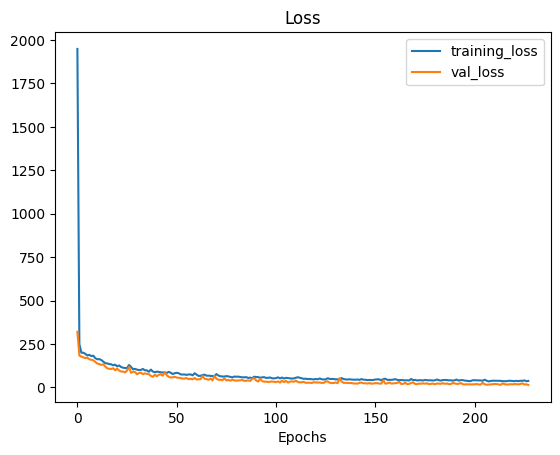

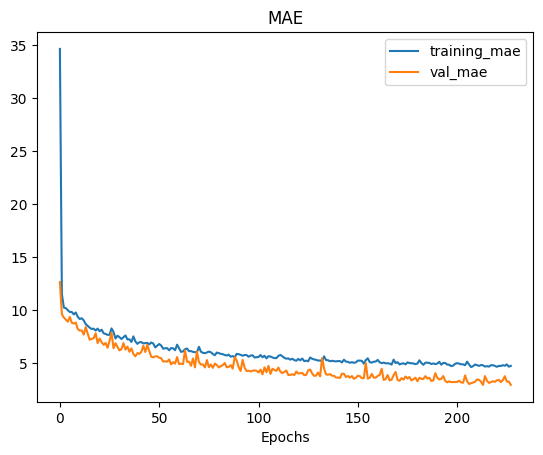

In [52]:
plot_loss_curves(history_result_4)

In [50]:
# with 300 epochs but with 32 frequency on hp.filter_signal - result: mae 5.588866034451262 and std 1.8936723096770496
def create_model_hyper(subject_dfs):
    """
    Apply k-fold cross validation, create the DL model and return it
    subject_dfs = dataset used
    """
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []

    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject

        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]

        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)

        train_labels = get_labels_segments_testing_hyper(train_df, 0, 4000)
        test_labels = get_labels_segments_testing_hyper(test_df, 0, 4000)
        train_data = get_subject_segments_testing_hyper(train_df, 0, 4000)
        test_data = get_subject_segments_testing_hyper(test_df, 0, 4000)

        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20)
        model = models.Sequential()
        model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='elu'))
        model.add(layers.Dropout(rate=0.5))
        model.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model.fit(train_data, train_labels, epochs=300, batch_size = 128, callbacks=[callback],
                            validation_data=(test_data, test_labels))

        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score, model
history_result_5, mae_result_5, loss_result_5, model_result_5 = create_model_hyper(subject_dataframes)

Epoch 1/300
32/32 [==============================] - 4s 98ms/step - loss: 2016.6959 - mae: 36.2456 - val_loss: 317.4234 - val_mae: 12.4991
Epoch 2/300
32/32 [==============================] - 3s 93ms/step - loss: 312.9274 - mae: 12.9685 - val_loss: 231.5223 - val_mae: 10.4893
Epoch 3/300
32/32 [==============================] - 3s 93ms/step - loss: 206.5129 - mae: 10.4772 - val_loss: 177.8874 - val_mae: 9.2448
Epoch 4/300
32/32 [==============================] - 3s 93ms/step - loss: 184.7188 - mae: 9.7031 - val_loss: 159.4530 - val_mae: 8.5361
Epoch 5/300
32/32 [==============================] - 3s 94ms/step - loss: 177.7731 - mae: 9.4286 - val_loss: 156.6114 - val_mae: 8.4185
Epoch 6/300
32/32 [==============================] - 3s 94ms/step - loss: 173.9470 - mae: 9.1841 - val_loss: 149.3932 - val_mae: 8.1846
Epoch 7/300
32/32 [==============================] - 3s 94ms/step - loss: 171.0004 - mae: 9.1679 - val_loss: 152.8518 - val_mae: 8.3588
Epoch 8/300
32/32 [=======================

In [51]:
np.average(mae_result_5)

5.803378314823492

In [49]:
np.std(mae_result_5)

1.8936723096770496

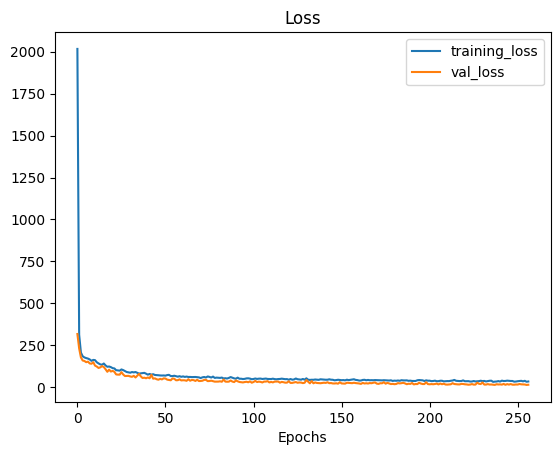

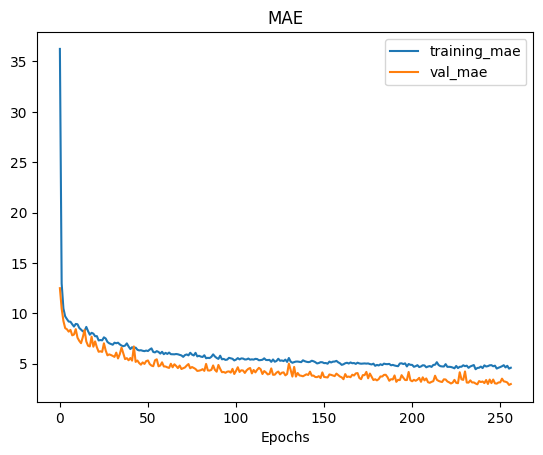

In [53]:
plot_loss_curves(history_result_5)

In [54]:
model_result_5.save("ppg_model_1_1")

INFO:tensorflow:Assets written to: ppg_model_1_1\assets


INFO:tensorflow:Assets written to: ppg_model_1_1\assets


In [55]:
model_result_5.save('ppg_model_1_1.keras')

In [ ]:
# with 300 epochs but with 32 frequency on hp.filter_signal - result: mae 5.588866034451262 and std 1.8936723096770496
def create_model_hyper(subject_dfs):
    """
    Apply k-fold cross validation, create the DL model and return it
    subject_dfs = dataset used
    """
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []

    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject

        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]

        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)

        train_labels = get_labels_segments_testing_hyper(train_df, 0, 4000)
        test_labels = get_labels_segments_testing_hyper(test_df, 0, 4000)
        train_data = get_subject_segments_testing_hyper(train_df, 0, 4000)
        test_data = get_subject_segments_testing_hyper(test_df, 0, 4000)

        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20)
        model = models.Sequential()
        model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='elu'))
        model.add(layers.Dropout(rate=0.5))
        model.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model.fit(train_data, train_labels, epochs=300, batch_size = 128, callbacks=[callback],
                            validation_data=(test_data, test_labels))

        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score, model
history_result_5, mae_result_5, loss_result_5, model_result_5 = create_model_hyper(subject_dataframes)

Epoch 1/300
32/32 [==============================] - 152s 5s/step - loss: 1821.5885 - mae: 34.2390 - val_loss: 393.8639 - val_mae: 14.1809
Epoch 2/300
32/32 [==============================] - 149s 5s/step - loss: 319.7890 - mae: 13.1873 - val_loss: 267.2924 - val_mae: 12.4407
Epoch 3/300
32/32 [==============================] - 147s 5s/step - loss: 230.1788 - mae: 11.0317 - val_loss: 173.3431 - val_mae: 9.1750
Epoch 4/300
32/32 [==============================] - 135s 4s/step - loss: 192.3709 - mae: 9.8866 - val_loss: 165.8510 - val_mae: 8.9483
Epoch 5/300
32/32 [==============================] - 139s 4s/step - loss: 190.4519 - mae: 9.8580 - val_loss: 172.2420 - val_mae: 9.1786
Epoch 6/300
32/32 [==============================] - 143s 4s/step - loss: 179.5611 - mae: 9.5565 - val_loss: 154.4317 - val_mae: 8.6498
Epoch 7/300
 3/32 [=>............................] - ETA: 2:02 - loss: 184.1275 - mae: 9.5795 

In [ ]:
# save the results to a pickle file